# 07 — Border Events Overlay
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

Overlaying Thai-Cambodia border conflict events (2568-2569)
with voting patterns in border amphoes (น้ำยืน, น้ำขุ่น).

Key question: Did voters in conflict-affected areas behave differently
from voters in non-border amphoes?

Note: This is a qualitative overlay — we can observe patterns
but cannot prove causation.

## 0 · Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
import datetime

RAW  = Path('../data-final')
OUT1  = Path('../data-processed/1')
OUT  = Path('../data-processed/7')
FIG  = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

df_const        = pd.read_csv(OUT1 / 'constituency_station.csv')
df_party        = pd.read_csv(OUT1 / 'partylist_station.csv')
const_by_amphoe = pd.read_csv(OUT1 / 'constituency_by_amphoe.csv')
cand_map        = pd.read_csv(OUT1 / 'candidate_mapping.csv')

color_map  = dict(zip(cand_map['party_name'],     cand_map['color_hex']))
cand_color = dict(zip(cand_map['candidate_name'], cand_map['color_hex']))

# Border vs non-border amphoe classification
BORDER_AMPHOES = ['อำเภอน้ำยืน', 'อำเภอน้ำขุ่น']
INLAND_AMPHOES = ['อำเภอทุ่งศรีอุดม', 'อำเภอสำโรง',
                  'อำเภอเดชอุดม (เฉพาะตำบลทุ่งเทิง)', 'ล่วงหน้านอกเขต']

print('Loaded OK')

Loaded OK


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Define Border Event Timeline

Events sourced from Thai PBS, Wikipedia (วิกฤตการณ์ชายแดนไทย–กัมพูชา พ.ศ. 2568–2569),
and Sanook/Isaan Insight news reports.

In [2]:
events = [
    {
        'date':        datetime.date(2025, 5, 28),
        'label':       '28 พ.ค.\nปะทะช่องบก ครั้งแรก\nทหารกัมพูชาเสียชีวิต 1',
        'severity':    'medium',
        'location':    'ช่องบก อ.น้ำยืน',
        'affects_ubon10': True,
    },
    {
        'date':        datetime.date(2025, 7, 23),
        'label':       '23 ก.ค.\nทหารไทยเหยียบกับระเบิด\nช่องอานม้า ขาขาด 1',
        'severity':    'high',
        'location':    'ช่องอานม้า อ.น้ำยืน',
        'affects_ubon10': True,
    },
    {
        'date':        datetime.date(2025, 7, 24),
        'label':       '24 ก.ค.\nปะทะหนัก ปิดด่านชายแดน 4 แห่ง\nF-16 โจมตีเป้าหมายกัมพูชา',
        'severity':    'critical',
        'location':    'ช่องบก/ช่องอานม้า',
        'affects_ubon10': True,
    },
    {
        'date':        datetime.date(2025, 12, 8),
        'label':       '8 ธ.ค.\nกัมพูชายิง BM-21\nรพ.น้ำยืน รพ.น้ำขุ่น ปิด',
        'severity':    'critical',
        'location':    'น้ำยืน/น้ำขุ่น',
        'affects_ubon10': True,
    },
    {
        'date':        datetime.date(2026, 2, 1),
        'label':       '1 ก.พ. 2569\nวันเลือกตั้งล่วงหน้า',
        'severity':    'election',
        'location':    'ทั่วเขต',
        'affects_ubon10': True,
    },
    {
        'date':        datetime.date(2026, 2, 8),
        'label':       '8 ก.พ. 2569\nวันเลือกตั้ง',
        'severity':    'election',
        'location':    'ทั่วเขต',
        'affects_ubon10': True,
    },
]

severity_colors = {
    'medium':   '#f0ad4e',
    'high':     '#e8823a',
    'critical': '#e84545',
    'election': '#4a90d9',
}

df_events = pd.DataFrame(events)
print(df_events[['date', 'label', 'severity', 'location']].to_string(index=False))

      date                                                             label severity            location
2025-05-28              28 พ.ค.\nปะทะช่องบก ครั้งแรก\nทหารกัมพูชาเสียชีวิต 1   medium     ช่องบก อ.น้ำยืน
2025-07-23               23 ก.ค.\nทหารไทยเหยียบกับระเบิด\nช่องอานม้า ขาขาด 1     high ช่องอานม้า อ.น้ำยืน
2025-07-24 24 ก.ค.\nปะทะหนัก ปิดด่านชายแดน 4 แห่ง\nF-16 โจมตีเป้าหมายกัมพูชา critical   ช่องบก/ช่องอานม้า
2025-12-08                8 ธ.ค.\nกัมพูชายิง BM-21\nรพ.น้ำยืน รพ.น้ำขุ่น ปิด critical      น้ำยืน/น้ำขุ่น
2026-02-01                                 1 ก.พ. 2569\nวันเลือกตั้งล่วงหน้า election             ทั่วเขต
2026-02-08                                         8 ก.พ. 2569\nวันเลือกตั้ง election             ทั่วเขต


## 2 · Border vs Inland — Constituency Vote Share Comparison

Do border amphoes vote differently from inland amphoes?

In [3]:
# Classify amphoes
const_by_amphoe['zone'] = const_by_amphoe['amphoe'].apply(
    lambda a: 'border' if a in BORDER_AMPHOES else 'inland'
)

# Vote share per zone per candidate
zone_total = const_by_amphoe.groupby('zone')['score'].sum().rename('zone_total')
zone_cand = (
    const_by_amphoe
    .groupby(['zone', 'candidate_name', 'party_name', 'color_hex'])['score']
    .sum()
    .reset_index()
    .merge(zone_total, on='zone')
)
zone_cand['vote_share_%'] = (zone_cand['score'] / zone_cand['zone_total'] * 100).round(2)

border = zone_cand[zone_cand['zone'] == 'border'].sort_values('cand_number' if 'cand_number' in zone_cand.columns else 'score', ascending=False)
inland = zone_cand[zone_cand['zone'] == 'inland'].sort_values('score', ascending=False)

print('=== Border Amphoes (น้ำยืน, น้ำขุ่น) ===')
print(zone_cand[zone_cand['zone']=='border'][['candidate_name','party_name','score','vote_share_%']].to_string(index=False))
print('\n=== Inland Amphoes ===')
print(zone_cand[zone_cand['zone']=='inland'][['candidate_name','party_name','score','vote_share_%']].to_string(index=False))

=== Border Amphoes (น้ำยืน, น้ำขุ่น) ===
         candidate_name     party_name  score  vote_share_%
นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ    351          0.88
           นายยิ่ง ภูผา   ประชาธิปัตย์     88          0.22
      นายวัชรพล เชื้อคง       เพื่อไทย   1321          3.30
   นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  36075         90.09
   นายสิโรตม์ แสนทวีสุข        ประชาชน   1231          3.07
         นายเกษม ฉิมพลี      ภูมิใจไทย    976          2.44

=== Inland Amphoes ===
         candidate_name     party_name  score  vote_share_%
นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ    536          1.52
           นายยิ่ง ภูผา   ประชาธิปัตย์    167          0.47
      นายวัชรพล เชื้อคง       เพื่อไทย   4326         12.27
   นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  24468         69.41
   นายสิโรตม์ แสนทวีสุข        ประชาชน   3618         10.26
         นายเกษม ฉิมพลี      ภูมิใจไทย   2135          6.06


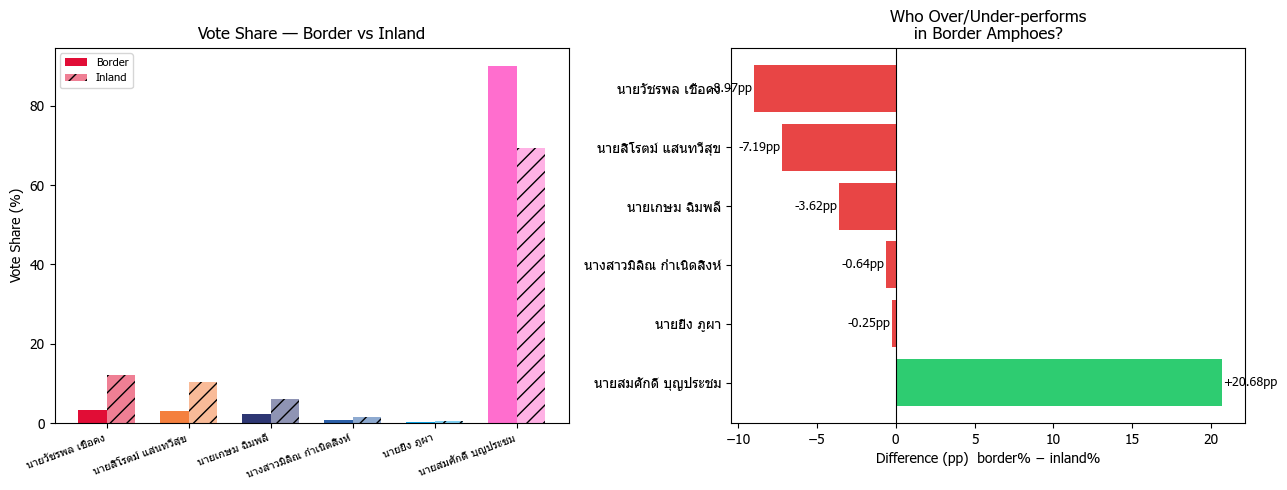

In [5]:
# Side-by-side comparison: border vs inland vote share
compare = zone_cand.pivot_table(
    index=['candidate_name', 'party_name', 'color_hex'],
    columns='zone',
    values='vote_share_%'
).reset_index().fillna(0)
compare['diff_pp'] = (compare['border'] - compare['inland']).round(2)
compare = compare.sort_values('diff_pp')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: side-by-side bars
x = np.arange(len(compare))
w = 0.35
ax = axes[0]
ax.bar(x - w/2, compare['border'],  width=w,
       color=compare['color_hex'].tolist(), label='Border', alpha=0.95)
ax.bar(x + w/2, compare['inland'],  width=w,
       color=compare['color_hex'].tolist(), label='Inland', alpha=0.5, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(compare['candidate_name'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Vote Share (%)')
ax.set_title('Vote Share — Border vs Inland')
ax.legend(fontsize=8)

# Right: diverging diff
colors = ['#e84545' if v < 0 else '#2ecc71' for v in compare['diff_pp']]
bars = axes[1].barh(compare['candidate_name'], compare['diff_pp'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Difference (pp)  border% − inland%')
axes[1].set_title('Who Over/Under-performs\nin Border Amphoes?')
for bar, val in zip(bars, compare['diff_pp']):
    offset = 0.1 if val >= 0 else -0.1
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIG / 'border_vs_inland_constituency.png', dpi=150)
plt.show()

## 3 · Border vs Inland — Party-list Comparison

In [6]:
df_party['zone'] = df_party['amphoe'].apply(
    lambda a: 'border' if a in BORDER_AMPHOES else 'inland'
)

zone_party_total = df_party.groupby('zone')['score'].sum() / 57
zone_party = (
    df_party.groupby(['zone', 'party_number', 'party_name'])['score']
    .sum().reset_index()
)
zone_party = zone_party.merge(
    zone_party_total.rename('zone_total'), on='zone'
)
zone_party['vote_share_%'] = (zone_party['score'] / zone_party['zone_total'] * 100).round(2)

# Top 10 parties overall
top10_nums = (
    df_party.groupby('party_number')['score'].sum()
    .sort_values(ascending=False).head(10).index.tolist()
)

party_compare = zone_party[zone_party['party_number'].isin(top10_nums)].pivot_table(
    index=['party_number', 'party_name'],
    columns='zone',
    values='vote_share_%'
).reset_index().fillna(0)
party_compare['diff_pp'] = (party_compare['border'] - party_compare['inland']).round(2)
party_compare = party_compare.sort_values('diff_pp')

print('=== Party-list: Border vs Inland (Top 10) ===')
print(party_compare[['party_name', 'border', 'inland', 'diff_pp']].to_string(index=False))

=== Party-list: Border vs Inland (Top 10) ===
    party_name  border  inland  diff_pp
      เพื่อไทย  214.81  617.08  -402.27
       ประชาชน  245.12  630.98  -385.86
พลังไทยรักชาติ   85.26  313.62  -228.36
     ภูมิใจไทย   63.01  114.61   -51.60
  เพื่อชาติไทย  112.99  156.81   -43.82
   ไทยสร้างไทย   84.64   94.67   -10.03
       ฟิวชั่น  110.09   98.17    11.92
     ก้าวอิสระ  147.55  135.29    12.26
เพื่อบ้านเมือง  171.87   53.44   118.43
     ไทรวมพลัง 2766.19 1531.33  1234.86


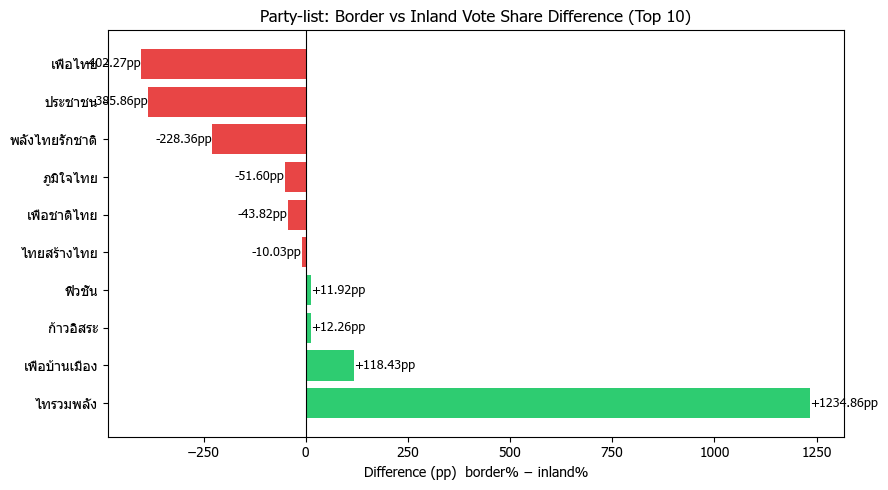

In [7]:
colors = ['#e84545' if v < 0 else '#2ecc71' for v in party_compare['diff_pp']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(party_compare['party_name'], party_compare['diff_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (pp)  border% − inland%')
ax.set_title('Party-list: Border vs Inland Vote Share Difference (Top 10)')
for bar, val in zip(bars, party_compare['diff_pp']):
    offset = 0.1 if val >= 0 else -0.1
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'border_vs_inland_partylist.png', dpi=150)
plt.show()

## 4 · Advance vs Election Day in Border Amphoes

Key question: after months of conflict, did border residents
turn out differently on advance day vs election day?
Compare advance/election-day split for border vs inland.

In [8]:
def zone_type_share(df, score_divisor=1):
    """Vote share by (zone × station_type) per candidate/party."""
    grp = (
        df.groupby(['zone', 'station_type'])['score']
        .sum().reset_index()
        .rename(columns={'score': 'total'})
    )
    grp['total_voters'] = grp['total'] / score_divisor
    return grp

# Constituency: score_divisor=6
const_zone_type = df_const.copy()
const_zone_type['zone'] = const_zone_type['amphoe'].apply(
    lambda a: 'border' if a in BORDER_AMPHOES else 'inland'
)

advance_border = const_zone_type[
    (const_zone_type['zone'] == 'border') &
    (const_zone_type['station_type'] == 'advance_out')
]['score'].sum() / 6

ed_border = const_zone_type[
    (const_zone_type['zone'] == 'border') &
    (const_zone_type['station_type'] == 'election_day')
]['score'].sum() / 6

advance_inland = const_zone_type[
    (const_zone_type['zone'] == 'inland') &
    (const_zone_type['station_type'] == 'advance_out')
]['score'].sum() / 6

ed_inland = const_zone_type[
    (const_zone_type['zone'] == 'inland') &
    (const_zone_type['station_type'] == 'election_day')
]['score'].sum() / 6

print('Note: advance_out stations have no amphoe breakdown → allocated to "inland" by default')
print(f'\nBorder  — election day est. voters: {ed_border:,.0f}')
print(f'Inland  — election day est. voters: {ed_inland:,.0f}')
print(f'Advance — total est. voters       : {(advance_border + advance_inland):,.0f}  (no amphoe split available)')

Note: advance_out stations have no amphoe breakdown → allocated to "inland" by default

Border  — election day est. voters: 6,674
Inland  — election day est. voters: 4,604
Advance — total est. voters       : 1,271  (no amphoe split available)


In [9]:
# Candidate share in border election_day stations
border_ed = const_zone_type[
    (const_zone_type['zone'] == 'border') &
    (const_zone_type['station_type'] == 'election_day')
]
border_ed_share = (
    border_ed.groupby(['candidate_name', 'party_name', 'color_hex'])['score']
    .sum().reset_index()
)
border_ed_share['vote_share_%'] = (
    border_ed_share['score'] / border_ed_share['score'].sum() * 100
).round(2)
border_ed_share = border_ed_share.sort_values('vote_share_%', ascending=False)

print('=== Candidate Share in Border Amphoes (Election Day) ===')
print(border_ed_share[['candidate_name', 'party_name', 'score', 'vote_share_%']].to_string(index=False))

=== Candidate Share in Border Amphoes (Election Day) ===
         candidate_name     party_name  score  vote_share_%
   นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  36075         90.09
      นายวัชรพล เชื้อคง       เพื่อไทย   1321          3.30
   นายสิโรตม์ แสนทวีสุข        ประชาชน   1231          3.07
         นายเกษม ฉิมพลี      ภูมิใจไทย    976          2.44
นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ    351          0.88
           นายยิ่ง ภูผา   ประชาธิปัตย์     88          0.22


## 5 · Event Timeline Visualization

Plot a horizontal timeline of border conflict events
relative to the election dates.

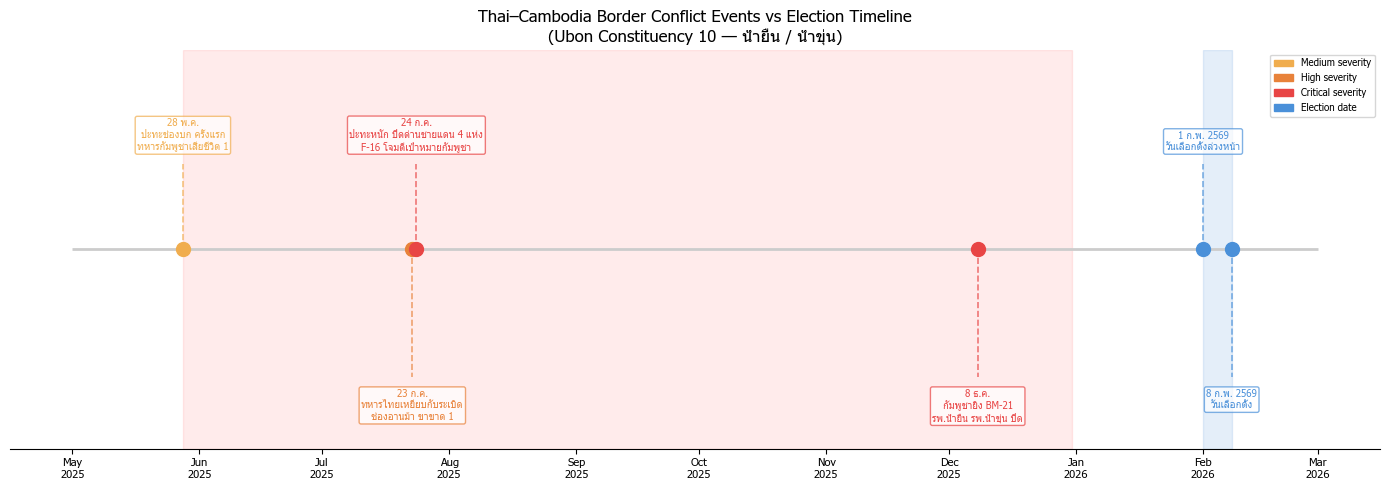

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# Draw timeline base
start = datetime.date(2025, 5, 1)
end   = datetime.date(2026, 3, 1)
ax.hlines(0, start.toordinal(), end.toordinal(), color='#cccccc', linewidth=2)

# Phase shading: conflict period
conflict_start = datetime.date(2025, 5, 28)
conflict_end   = datetime.date(2025, 12, 31)
ax.axvspan(conflict_start.toordinal(), conflict_end.toordinal(),
           alpha=0.08, color='red', label='Conflict period')

# Election window shading
ax.axvspan(datetime.date(2026, 2, 1).toordinal(),
           datetime.date(2026, 2, 8).toordinal(),
           alpha=0.15, color='#4a90d9', label='Election window')

# Plot events
for i, ev in enumerate(events):
    x     = ev['date'].toordinal()
    color = severity_colors[ev['severity']]
    y_off = 0.3 if i % 2 == 0 else -0.45   # alternate above/below

    ax.plot(x, 0, 'o', color=color, markersize=10, zorder=5)
    ax.vlines(x, 0, y_off, color=color, linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(x, y_off + (0.04 if y_off > 0 else -0.04),
            ev['label'], ha='center', va='bottom' if y_off > 0 else 'top',
            fontsize=7, color=color,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec=color))

# X-axis ticks (monthly)
months = pd.date_range('2025-05-01', '2026-03-01', freq='MS')
ax.set_xticks([d.toordinal() for d in months.date])
ax.set_xticklabels([d.strftime('%b\n%Y') for d in months.date], fontsize=8)

# Legend
legend_patches = [
    mpatches.Patch(color=severity_colors['medium'],   label='Medium severity'),
    mpatches.Patch(color=severity_colors['high'],     label='High severity'),
    mpatches.Patch(color=severity_colors['critical'], label='Critical severity'),
    mpatches.Patch(color=severity_colors['election'], label='Election date'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=7)

ax.set_ylim(-0.7, 0.7)
ax.set_yticks([])
ax.set_title('Thai–Cambodia Border Conflict Events vs Election Timeline\n(Ubon Constituency 10 — น้ำยืน / น้ำขุ่น)')
ax.spines[['left', 'right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG / 'border_event_timeline.png', dpi=150)
plt.show()

## 6 · Tambon-level Deep Dive — น้ำยืน vs น้ำขุ่น

Compare voting patterns between the two border amphoes themselves.
น้ำยืน is the epicenter (ช่องบก, ช่องอานม้า) — did it vote differently from น้ำขุ่น?

In [11]:
const_by_tambon = pd.read_csv(OUT1 / 'constituency_by_tambon.csv')

border_tambon = const_by_tambon[
    const_by_tambon['amphoe'].isin(BORDER_AMPHOES)
].copy()

amphoe_total = border_tambon.groupby('amphoe')['score'].sum().rename('amphoe_total')
border_tambon = border_tambon.merge(amphoe_total, on='amphoe')
border_tambon['vote_share_%'] = (
    border_tambon['score'] / border_tambon['amphoe_total'] * 100
).round(2)

# Winner per amphoe
border_winner = (
    border_tambon.sort_values('score', ascending=False)
    .groupby('amphoe').first().reset_index()
    [['amphoe', 'candidate_name', 'party_name', 'score', 'vote_share_%']]
)
print('=== Winner: น้ำยืน vs น้ำขุ่น ===')
print(border_winner.to_string(index=False))

=== Winner: น้ำยืน vs น้ำขุ่น ===
      amphoe       candidate_name     party_name  score  vote_share_%
อำเภอน้ำขุ่น นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   3130         27.09
 อำเภอน้ำยืน นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   6654         23.36


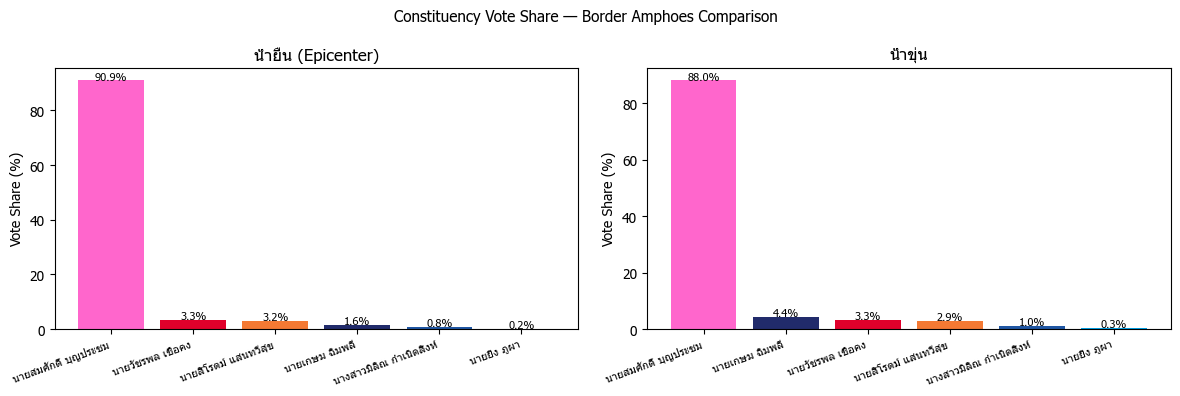

In [12]:
# Full breakdown: น้ำยืน vs น้ำขุ่น
namyuen = border_tambon[border_tambon['amphoe'] == 'อำเภอน้ำยืน']
namkhun = border_tambon[border_tambon['amphoe'] == 'อำเภอน้ำขุ่น']

ny_share = namyuen.groupby(['candidate_name','color_hex'])['vote_share_%'].sum().reset_index()
nk_share = namkhun.groupby(['candidate_name','color_hex'])['vote_share_%'].sum().reset_index()

ny_share = ny_share.sort_values('vote_share_%', ascending=False)
nk_share = nk_share.sort_values('vote_share_%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, df_s, title in zip(axes, [ny_share, nk_share], ['น้ำยืน (Epicenter)', 'น้ำขุ่น']):
    colors = df_s['color_hex'].tolist()
    bars = ax.bar(df_s['candidate_name'], df_s['vote_share_%'], color=colors)
    ax.set_title(title)
    ax.set_ylabel('Vote Share (%)')
    plt.sca(ax)
    plt.xticks(rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, df_s['vote_share_%']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}%', ha='center', fontsize=8)

fig.suptitle('Constituency Vote Share — Border Amphoes Comparison', fontsize=11)
plt.tight_layout()
plt.savefig(FIG / 'border_namyuen_vs_namkhun.png', dpi=150)
plt.show()

## 7 · Key Observations

In [13]:
print('=== KEY OBSERVATIONS ===\n')

# 1. Border vs inland winner share
border_winner_share = zone_cand[
    (zone_cand['zone'] == 'border')
].sort_values('vote_share_%', ascending=False).iloc[0]

inland_winner_share = zone_cand[
    (zone_cand['zone'] == 'inland')
].sort_values('vote_share_%', ascending=False).iloc[0]

print(f'1. Winner share in BORDER amphoes : {border_winner_share["candidate_name"]} {border_winner_share["vote_share_%"]}%')
print(f'   Winner share in INLAND amphoes : {inland_winner_share["candidate_name"]} {inland_winner_share["vote_share_%"]}%')

# 2. Conflict timeline proximity to election
days_to_election = (datetime.date(2026, 2, 8) - datetime.date(2025, 12, 8)).days
print(f'\n2. Most severe event (8 ธ.ค. — รพ.ปิด) was {days_to_election} days before election day')
print(f'   = {days_to_election//7} weeks — voters likely still remembered')

# 3. น้ำยืน vs น้ำขุ่น diff
ny_top = ny_share.iloc[0]
nk_top = nk_share.iloc[0]
print(f'\n3. น้ำยืน (epicenter) winner share: {ny_top["vote_share_%"]:.1f}%')
print(f'   น้ำขุ่น winner share           : {nk_top["vote_share_%"]:.1f}%')

=== KEY OBSERVATIONS ===

1. Winner share in BORDER amphoes : นายสมศักดิ์ บุญประชม 90.09%
   Winner share in INLAND amphoes : นายสมศักดิ์ บุญประชม 69.41%

2. Most severe event (8 ธ.ค. — รพ.ปิด) was 62 days before election day
   = 8 weeks — voters likely still remembered

3. น้ำยืน (epicenter) winner share: 90.9%
   น้ำขุ่น winner share           : 88.0%


## 8 · Border Insight Summary — ตำบลชายแดน vs ไม่ชายแดน

In [15]:
# Constituency: all 5 amphoes ranked by winner share
amphoe_summary = (
    const_by_amphoe
    .sort_values('score', ascending=False)
    .groupby('amphoe')
    .agg(
        winner=('candidate_name', 'first'),
        winner_party=('party_name', 'first'),
        winner_votes=('score', 'first'),
        total_votes=('score', 'sum'),
    )
    .reset_index()
)
amphoe_summary['winner_share_%'] = (
    amphoe_summary['winner_votes'] / amphoe_summary['total_votes'] * 100
).round(2)
amphoe_summary['zone'] = amphoe_summary['amphoe'].apply(
    lambda a: 'border' if a in BORDER_AMPHOES else 'inland'
)
amphoe_summary = amphoe_summary.sort_values('winner_share_%', ascending=False)

print('=== All Amphoes — Winner Share + Zone ===')
print(amphoe_summary[['amphoe', 'zone', 'winner', 'winner_party',
                       'winner_votes', 'total_votes', 'winner_share_%']].to_string(index=False))

=== All Amphoes — Winner Share + Zone ===
          amphoe   zone               winner   winner_party  winner_votes  total_votes  winner_share_%
     อำเภอน้ำยืน border นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง         25904        28486           90.94
    อำเภอน้ำขุ่น border นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง         10171        11556           88.01
อำเภอทุ่งศรีอุดม inland นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง         10136        12679           79.94
      อำเภอสำโรง inland นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง          9673        14945           64.72
  ล่วงหน้านอกเขต inland นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง          4659         7626           61.09


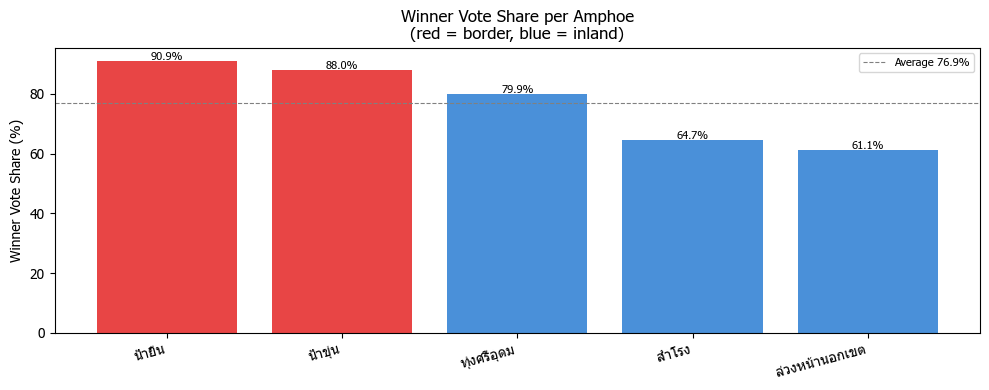

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

zone_colors = {'border': '#e84545', 'inland': '#4a90d9'}
bar_colors  = [zone_colors[z] for z in amphoe_summary['zone']]

bars = ax.bar(
    amphoe_summary['amphoe'].str.replace('อำเภอ', '').str.replace(' (เฉพาะตำบลทุ่งเทิง)', ''),
    amphoe_summary['winner_share_%'],
    color=bar_colors
)
ax.set_ylabel('Winner Vote Share (%)')
ax.set_title('Winner Vote Share per Amphoe\n(red = border, blue = inland)')
ax.axhline(amphoe_summary['winner_share_%'].mean(), color='gray',
           linestyle='--', linewidth=0.8, label=f"Average {amphoe_summary['winner_share_%'].mean():.1f}%")
ax.legend(fontsize=8)

for bar, val in zip(bars, amphoe_summary['winner_share_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=8)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG / 'border_winner_share_all_amphoe.png', dpi=150)
plt.show()

In [17]:
# Avg winner share: border vs inland
print('=== Average Winner Share ===')
print(amphoe_summary.groupby('zone')['winner_share_%'].mean().round(2))

# Party-list: ไทรวมพลัง share border vs inland
party21_by_amphoe = (
    df_party[df_party['party_number'] == 21]
    .groupby('amphoe')['score'].sum()
    .reset_index()
    .rename(columns={'score': 'party21_votes'})
)
party_all_by_amphoe = (
    df_party.groupby('amphoe')['score'].sum()
    .reset_index()
    .rename(columns={'score': 'party_total'})
)
party21_share = party21_by_amphoe.merge(party_all_by_amphoe, on='amphoe')
party21_share['share_%'] = (party21_share['party21_votes'] / party21_share['party_total'] * 100 * 57).round(2)
party21_share['zone'] = party21_share['amphoe'].apply(
    lambda a: 'border' if a in BORDER_AMPHOES else 'inland'
)

print('\n=== ไทรวมพลัง Party-list Share per Amphoe ===')
print(party21_share[['amphoe', 'zone', 'share_%']].sort_values('share_%', ascending=False).to_string(index=False))
print('\nAvg by zone:')
print(party21_share.groupby('zone')['share_%'].mean().round(2))

=== Average Winner Share ===
zone
border    89.48
inland    68.58
Name: winner_share_%, dtype: float64

=== ไทรวมพลัง Party-list Share per Amphoe ===
          amphoe   zone  share_%
     อำเภอน้ำยืน border  2809.73
    อำเภอน้ำขุ่น border  2653.10
อำเภอทุ่งศรีอุดม inland  2086.24
  ล่วงหน้านอกเขต inland  1484.71
      อำเภอสำโรง inland  1097.17

Avg by zone:
zone
border    2731.42
inland    1556.04
Name: share_%, dtype: float64


## 9 · Export

In [18]:
compare.to_csv(OUT / 'border_vs_inland_constituency.csv', index=False, encoding='utf-8-sig')
party_compare.to_csv(OUT / 'border_vs_inland_partylist.csv', index=False, encoding='utf-8-sig')
border_tambon.to_csv(OUT / 'border_tambon_detail.csv', index=False, encoding='utf-8-sig')
df_events.to_csv(OUT / 'border_events_timeline.csv', index=False, encoding='utf-8-sig')
amphoe_summary.to_csv(OUT / 'border_amphoe_summary.csv', index=False, encoding='utf-8-sig')
party21_share.to_csv(OUT / 'border_party21_share.csv',   index=False, encoding='utf-8-sig')

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `border_vs_inland_constituency.csv` | Vote share diff border vs inland per candidate |
| `border_vs_inland_partylist.csv` | Party-list diff border vs inland (top 10) |
| `border_tambon_detail.csv` | Tambon-level detail for border amphoes |
| `border_events_timeline.csv` | Border conflict event records |
| `border_amphoe_summary.csv` | Winner share + zone per amphoe |
| `border_party21_share.csv` | ไทรวมพลัง party-list share per amphoe |

